In [5]:
import numpy as np
import requests
from seaborn import barplot
import seaborn as sns
import matplotlib.pyplot as plt
url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-07-07/coffee_ratings.csv'

with requests.get(url, stream=True) as r:
    r.raise_for_status()
    with open('coffee_ratings.csv', 'wb') as file:
        for chunk in r.iter_content(chunk_size=8192):
            file.write(chunk)

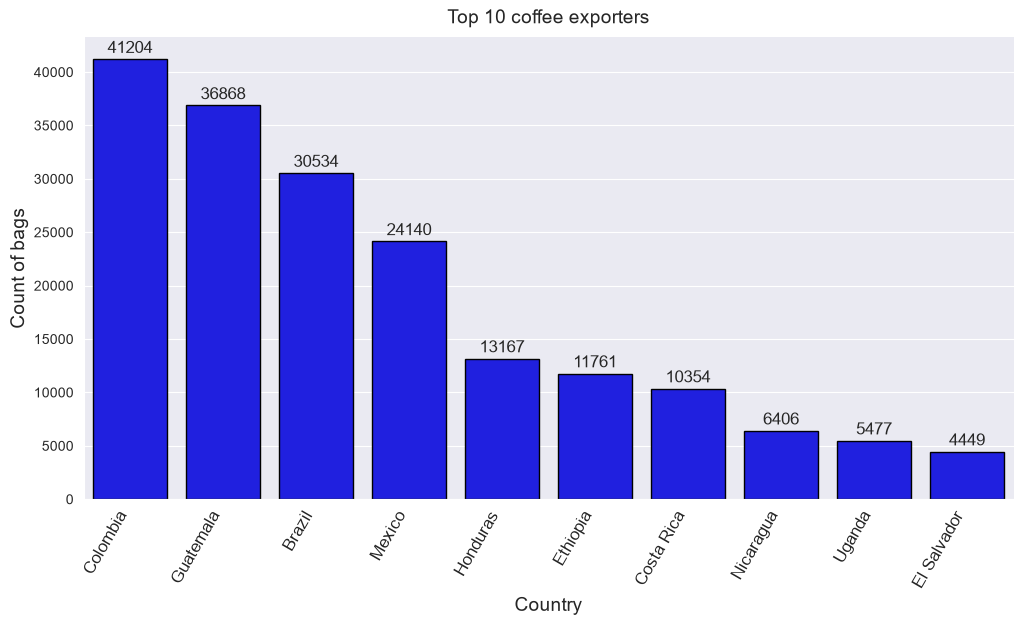

In [61]:
import pandas as pd

df = pd.read_csv('coffee_ratings.csv')

top_exporters = df.groupby(by='country_of_origin')['number_of_bags'].sum()
top_exporters = top_exporters.sort_values(ascending=False).head(10)
pd.set_option('display.max_columns', None)
# top_exporters.first()
# top_exporters
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=top_exporters.index,
    y=top_exporters.values,
    color = 'blue',
    edgecolor='black'
)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom', xytext= (0,2), textcoords='offset points',
        fontsize=12
    )

plt.title('Top 10 coffee exporters', fontsize=14, pad=10)
plt.ylabel('Count of bags', fontsize=14)
plt.xlabel('Country', fontsize=14)

plt.xticks(rotation=60, ha='right', fontsize=12)




(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]),
 [Text(0, 0.5, 'aroma'),
  Text(0, 1.5, 'flavor'),
  Text(0, 2.5, 'aftertaste'),
  Text(0, 3.5, 'acidity'),
  Text(0, 4.5, 'body'),
  Text(0, 5.5, 'balance'),
  Text(0, 6.5, 'cupper_points'),
  Text(0, 7.5, 'total_cup_points')])

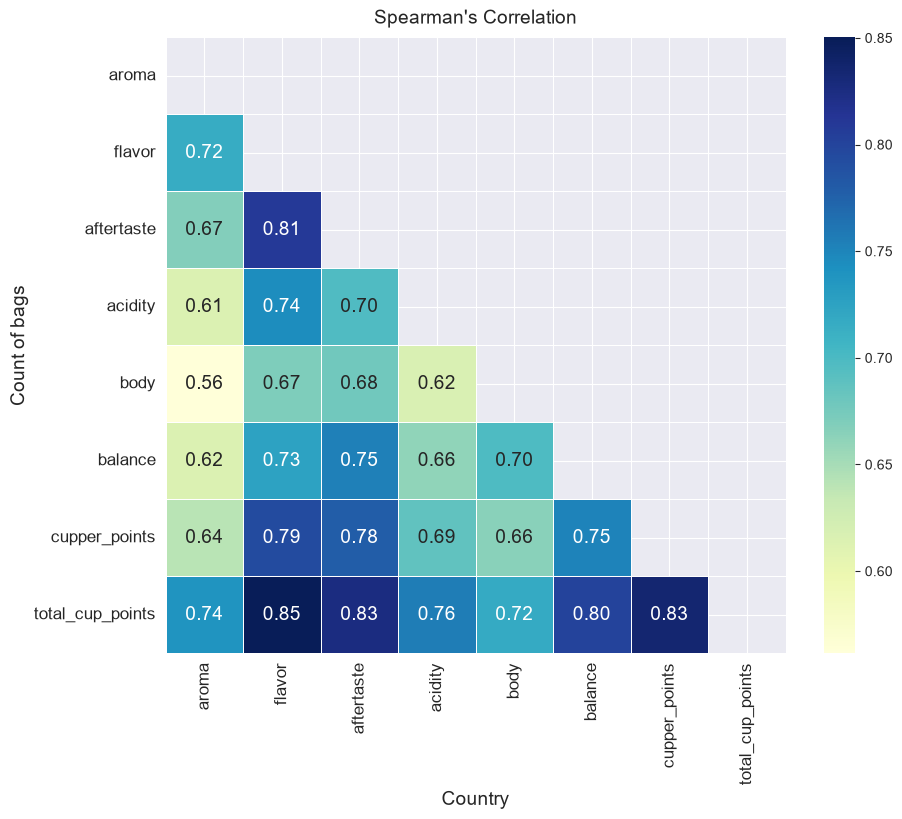

In [89]:
import numpy as np
coffee_columns = ['aroma', 'flavor', 'aftertaste', 'acidity', 'body',
               'balance', 'cupper_points', 'total_cup_points']

corr_matrix = df[coffee_columns].corr(method="spearman")

high_corr = (corr_matrix >= 0.65) & (corr_matrix < 1.0)
selected = high_corr.columns[high_corr.any()].tolist()
final_matrix = df[selected].corr(method="spearman")

mask = np.triu(np.ones_like(final_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    final_matrix,
    annot=True,
    fmt='.2f',
    mask=mask,
    cmap='YlGnBu',
    linewidths=0.5,
    annot_kws={'size': 14}
)
plt.title("Spearman's Correlation", fontsize=14, pad=10)
plt.ylabel('Count of bags', fontsize=14)
plt.xlabel('Country', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


color,Blue-Green,Bluish-Green,Green
species,,,
Arabica,82.706585,82.652411,81.898118
Robusta,79.360000,81.335000,81.458000


(array([0, 1]), [Text(0, 0, 'Arabica'), Text(1, 0, 'Robusta')])

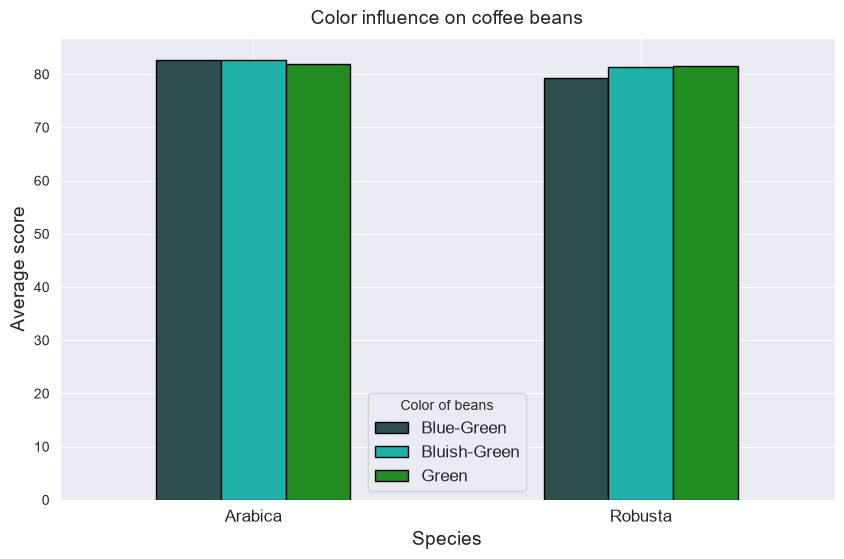

In [112]:
pivot_df = df.pivot_table(
    index = 'species',
    columns = 'color',
    values = 'total_cup_points',
    aggfunc = 'mean'
)

my_colors = ['#2F4F4F', '#20B2AA', '#228B22']

display(pivot_df)
plt.figure(figsize=(10, 6))

pivot_df.plot(kind='bar', ax= plt.gca(), color = my_colors, edgecolor = 'black')

plt.title('Color influence on coffee beans', fontsize=14, pad=10)
plt.ylabel('Average score', fontsize=14)
plt.xlabel('Species', fontsize=14)

plt.legend(title = 'Color of beans', fontsize=12 )
# plt.legend(loc= 'upper right', bbox_to_anchor=(1.05, 1)) /////// for me
plt.xticks(fontsize=12, rotation=0)

# Висновок: Гіпотеза про вплив кольору не підтвердилася. Незалежно від того, зелені це зерна, синьо-зелені чи блакитно-зелені, дегустатори ставлять їм приблизно однакові бали.


In [ ]:
# не доробив до кінця, бо вже почав робити степ проект(